# Chapter 21 — SETI: The Search for Technosignatures

!!! info "Before you start"
    **Prerequisites:** Ch 3 (Signals, Noise & the Radiometer Equation) · **Maths Lab:** Lab B (Matched Filtering) · **~45 min** · **Intermediate**

In [Chapter 18](18_fast_radio_bursts.ipynb) we hunted a *natural* transient — a
millisecond flash from another galaxy — by de-dispersing across thousands of trial
dispersion measures and watching a matched filter spike. This chapter takes that
same way of thinking — *try every member of a parameter family, integrate, look for
the spike* — and points it at a very different question: **is anyone out there
transmitting?**

The radio search for extraterrestrial intelligence (**SETI**) is, at bottom, a
search for a kind of signal that **nature does not make**. Astrophysical processes
— synchrotron, free-free, thermal, spectral lines broadened by motion — are
*broadband*: their power is spread across many megahertz. A **transmitter** is the
opposite. To concentrate energy and be unmistakably artificial, it radiates in a
single, exquisitely **narrow** band — a tone perhaps a few hertz wide in a billion.
That narrowness is the whole game. A signal confined to a single fine channel, with
no natural mechanism to put it there, is a **technosignature**.

We met a sketch of this in [Chapter 16](16_data_formats_and_ecosystem.ipynb): a
ten-line de-drift demo and the GUPPI/`turboSETI`/Breakthrough Listen pipeline that
runs it at scale. This chapter is the full treatment — the *physics* of why a real
signal **drifts**, the **drift-rate matched filter** that recovers it, the
**ON/OFF cadence** that rejects the ocean of human interference, and the
**Drake equation** that tells us how hopeful (or not) to be.

### Learning goals

By the end of this chapter you will be able to:

- explain why a radio technosignature search looks for **narrowband** signals
  (nature makes broadband; transmitters make narrowband);
- lay out the SETI **search space** — frequency $\times$ time $\times$ **Doppler
  drift** $\times$ sky — and say why it is so vast;
- read a drifting tone off a high-resolution **waterfall** and explain the
  **Doppler drift** (planetary rotation and orbit $\to$ Hz s$^{-1}$);
- run the **drift-rate matched filter** (`drift_search` / `dedrift`) and read the
  S/N-vs-drift curve that peaks at the true drift — the toy version of `turboSETI`;
- reject interference with an **ON/OFF cadence**: a real signal appears *only* in
  the ON-target scans (`cadence_detection`);
- use the **Drake equation** as a back-of-envelope and feel the size of its
  uncertainties.

This chapter runs **end-to-end offline** on the base environment. Every signal is
simulated with [`jansky.seti`](../src/jansky/seti.py) — the same `drifting_tone` /
`dedrift` / `drift_search` / `cadence_detection` helpers that `turboSETI` mirrors at
scale.

## 1. Orientation — the haystack, and the people who searched it

### Why narrowband

The single most important idea in radio SETI is a **negative** one: there is no
known natural process that emits a coherent signal confined to a band only a few
hertz wide. Stars, gas clouds, jets, even the famous spectral lines all spread their
power over kilohertz to gigahertz. So if you find a signal that is *narrow* — a
spike one fine channel wide, persisting in time — you have found something that, as
far as we know, a transmitter has to make. The search strategy follows directly:
**channelise as finely as you can** (sub-hertz channels over a wide band) and look
for power piled into a single channel.

### The haystack: frequency × time × drift × sky

Jill Tarter called SETI a "nine-dimensional haystack," but four axes capture the
essentials:

$$
\underbrace{\nu}_{\text{which frequency?}}\;\times\;
\underbrace{t}_{\text{when?}}\;\times\;
\underbrace{\dot\nu}_{\text{which drift rate?}}\;\times\;
\underbrace{(\alpha,\delta)}_{\text{where on the sky?}}
$$

- **Frequency.** The radio window spans ~1 MHz to ~100 GHz; a transmitter could be
  anywhere in it. The classic guess is the **"water hole"** between the H line
  (1420 MHz) and the OH lines (~1612–1720 MHz) — a quiet band that two
  water-based civilisations might both find natural.
- **Time.** A beacon may be intermittent; you only see it if you are looking when it
  is on.
- **Drift rate $\dot\nu$.** Because of relative acceleration (next section), the
  signal's frequency *ramps*. You do not know the rate, so you must search a range.
- **Sky.** Billions of stars, each a pointing.

Multiply these out and you get a search volume so large that SETI has always been a
story of clever ways to cut it down.

### The searchers

| Year | Milestone | Where |
|---|---|---|
| **1960** | **Project Ozma** — Frank Drake points an 85-ft dish at $\tau$ Ceti and $\epsilon$ Eridani at 1420 MHz: the first modern radio SETI | Green Bank |
| **1961** | The **Drake equation** is written for a SETI meeting — a way to organise the unknowns (Section 5) | Green Bank |
| **1977** | The **"Wow!" signal** — a 72-second, ~1420 MHz narrowband burst, 30σ above noise, never repeated — recorded by the **Big Ear** transit telescope | Ohio State |
| **2007–** | The **Allen Telescope Array (ATA)** — 42 × 6.1 m dishes at Hat Creek, the first array *purpose-built* for SETI | SETI Institute |
| **2015–** | **Breakthrough Listen** — a \$100M survey of a million nearby stars, using the **GBT**, **Parkes "Murriyang"**, and now **MeerKAT** and **FAST**, running `turboSETI` over Doppler-drift space | Berkeley SETI |

The **"Wow!"** signal (Ehman, Big Ear) is the most famous candidate in the field's
history: a single strong narrowband detection at the H line, in one of the two feed
horns, that exactly matched the profile of a point source drifting through the beam —
and that *never came back* despite many re-observations. With no repeat, it can be
neither confirmed nor explained, which is precisely the lesson of Section 4: one
detection is not a discovery.

> **Facilities and context.** The Allen Telescope Array, FAST (the 500 m dish that
> Breakthrough Listen now uses), MeerKAT, the GBT and Parkes are catalogued in
> [`docs/telescopes.md`](https://github.com/joebarbere/jansky/blob/main/docs/telescopes.md);
> the Big Ear (now demolished) is in its historic section. The SETI projects, the
> SETI Institute, and Berkeley's Breakthrough Listen are in
> [`docs/projects.md`](https://github.com/joebarbere/jansky/blob/main/docs/projects.md)
> and [`docs/resources.md`](https://github.com/joebarbere/jansky/blob/main/docs/resources.md),
> with the "Wow!"/SETI thread running through
> [`docs/papers-timeline.md`](https://github.com/joebarbere/jansky/blob/main/docs/papers-timeline.md).

## Setting up

We import the scientific stack and the `jansky` helpers, call
`plotting.use_jansky_style()` so the figures match the rest of the course, and seed
**every** random generator so the chapter is reproducible. The whole chapter runs on
the base environment with no network — all signals are simulated with
[`jansky.seti`](../src/jansky/seti.py).

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

from jansky import seti, plotting

plotting.use_jansky_style()

# One seed for the whole chapter -- 1960 is Project Ozma, the first radio SETI search.
SEED = 1960
rng = np.random.default_rng(SEED)

print("jansky.seti provides:", ", ".join(seti.__all__))

jansky.seti provides: drifting_tone, dedrift, drift_search, DriftSearchResult, cadence_detection


## 2. A drifting signal

### Why a beacon drifts in frequency

Imagine a transmitter on a planet, emitting at a perfectly fixed rest frequency
$f_0$. We never receive $f_0$ exactly, because the transmitter and our receiver are
**accelerating** relative to one another. The planet **spins** (its surface velocity
toward us changes through the day) and **orbits** its star; the Earth spins and
orbits the Sun. The line-of-sight velocity $v(t)$ therefore changes with time, and
the **Doppler effect** turns that into a changing observed frequency:

$$
f_{\text{obs}}(t) \;=\; f_0\left(1 - \frac{v(t)}{c}\right)
\;\approx\; f_0 - \dot f\, t,
\qquad
\dot f \;=\; \frac{f_0}{c}\,\frac{dv}{dt}\;=\;\frac{f_0\,a_{\parallel}}{c},
$$

where $a_\parallel$ is the relative line-of-sight **acceleration**. Over a short
observation the velocity ramp is nearly linear, so the frequency ramps linearly too:
the signal has a **drift rate** $\dot f$ in **Hz s$^{-1}$**. Plug in numbers —
$f_0 \sim 1.4$ GHz, and accelerations from planetary rotation/orbit of order
$10^{-2}$ to a few m s$^{-2}$ — and you get drift rates of a fraction of a Hz s$^{-1}$
up to a few Hz s$^{-1}$. Breakthrough Listen searches roughly $\pm 4$ Hz s$^{-1}$.

This is the crucial discriminator built into physics: a signal *from the sky* drifts,
while a *fixed* terrestrial transmitter (sharing our motion) tends to sit in one
channel. On a high-resolution **waterfall** — time down, fine frequency across — a
drifting tone traces a **sloped diagonal line**.

### Making one

`seti.drifting_tone` synthesises exactly this: a `(n_time, n_freq)` waterfall of
Gaussian noise with an optional narrowband tone that starts at channel `f0` and
drifts at `drift_rate` **channels per time sample**. We make a faint one — its
per-row amplitude is comparable to the noise, so in any single row it is invisible —
and plot it with `plotting.show_image`.

In [2]:
# Waterfall geometry: time (rows) x fine frequency (columns).
N_TIME = 64          # integrations (time samples)
N_FREQ = 256         # fine frequency channels
TRUE_DRIFT = 0.5     # channels per time sample -- the diagonal's slope
F0 = 40.0            # starting channel of the tone
SNR = 4.0            # peak tone amplitude (in noise-sigma units); faint per-row
WIDTH = 1.5          # line width in channels

waterfall = seti.drifting_tone(
    N_TIME, N_FREQ,
    drift_rate=TRUE_DRIFT,
    f0=F0, snr=SNR, width=WIDTH,
    present=True,
    seed=SEED,
)

print(f"waterfall shape (time, freq): {waterfall.shape}")
print(f"injected tone: start channel {F0:.0f}, drift {TRUE_DRIFT} channels/sample,")
print(f"  peak amplitude {SNR} sigma, width {WIDTH} channels")

# How far does it drift over the whole observation?
total_drift = TRUE_DRIFT * (N_TIME - 1)
print(f"over {N_TIME} samples the tone sweeps {total_drift:.1f} channels "
      f"(from {F0:.0f} to {F0 + total_drift:.0f})")

waterfall shape (time, freq): (64, 256)
injected tone: start channel 40, drift 0.5 channels/sample,
  peak amplitude 4.0 sigma, width 1.5 channels
over 64 samples the tone sweeps 31.5 channels (from 40 to 72)


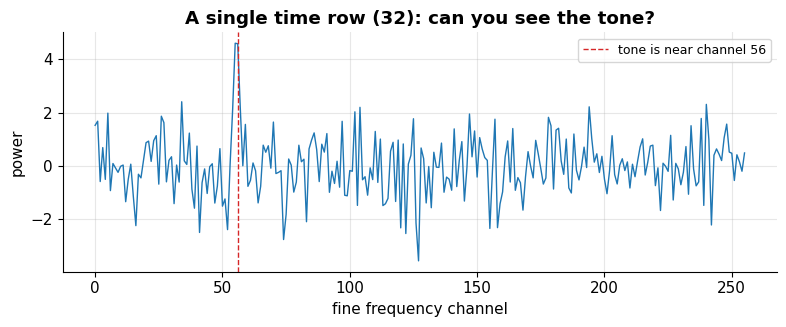

In [3]:
# A single time row: the tone is buried in the noise.
fig, ax = plt.subplots(figsize=(8, 3.4))
row = N_TIME // 2
ax.plot(waterfall[row], color="#1f77b4", lw=1)
expected_chan = F0 + TRUE_DRIFT * row
ax.axvline(expected_chan, color="#d62728", ls="--", lw=1,
           label=f"tone is near channel {expected_chan:.0f}")
ax.set_xlabel("fine frequency channel")
ax.set_ylabel("power")
ax.set_title(f"A single time row ({row}): can you see the tone?")
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

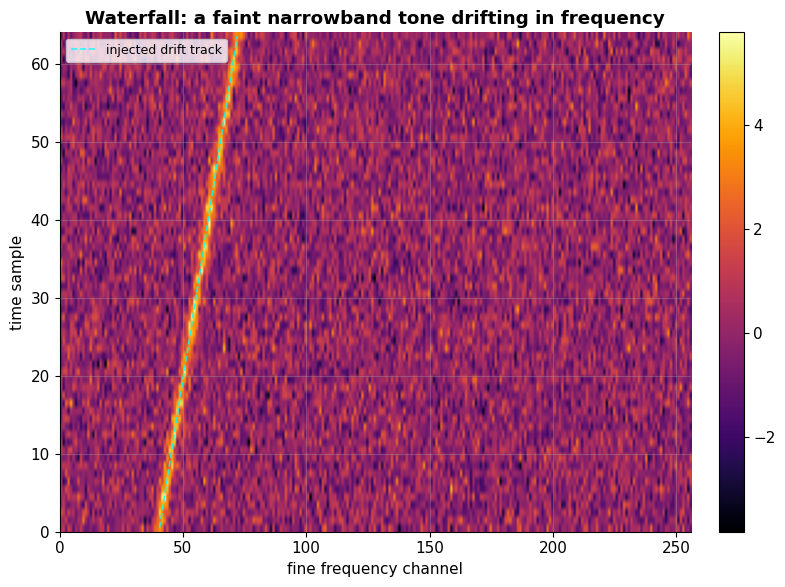

In [4]:
# The full waterfall: now the drifting diagonal is visible to the eye.
fig, ax = plt.subplots(figsize=(8, 6))
plotting.show_image(
    waterfall, ax=ax, aspect="auto", cmap="inferno", origin="lower",
    extent=[0, N_FREQ, 0, N_TIME],
    title="Waterfall: a faint narrowband tone drifting in frequency",
)
# Overlay the true drift track for reference.
t = np.arange(N_TIME)
ax.plot(F0 + TRUE_DRIFT * t + 0.5, t + 0.5, color="cyan", ls="--", lw=1.2,
        alpha=0.8, label="injected drift track")
ax.set_xlabel("fine frequency channel")
ax.set_ylabel("time sample")
ax.legend(loc="upper left", fontsize=9)
fig.tight_layout()
plt.show()

In a single row the tone is lost in the noise, but stacked into the full
waterfall the **diagonal** stands out: the signal marches steadily across channels as
time advances. That slope *is* the Doppler drift. A fixed terrestrial interferer
would instead draw a perfectly **vertical** line. The next section turns "stare at the
diagonal" into an algorithm.

## 3. The drift search — a matched filter for the slope

We do not know the drift rate in advance, so we **search** for it. The detector is a
matched filter built from one operation, `seti.dedrift`:

> for a trial drift rate $d$, shift each time row $t$ back by $\mathrm{round}(d\,t)$
> channels — undoing the assumed drift — and **sum the rows** into a 1-D spectrum.

At the **true** drift, every row's contribution to the tone lands in the *same*
channel: the signal adds coherently and integrates into one tall **spike**, its
height growing like $\sqrt{N_{\text{time}}}$ relative to the noise. At a **wrong**
drift the tone is sheared across many channels and **washes out** into the noise
floor. So the recipe is: de-drift at many trial rates, take the peak S/N of each
integrated spectrum, and the trial that maximises it recovers the drift.

`seti.drift_search` does the loop and returns a `DriftSearchResult` with the trial
grid, the S/N at each trial, and the best `(drift, snr)`. **This is exactly what
`turboSETI` does** ([Chapter 16](16_data_formats_and_ecosystem.ipynb)) — at scale,
over filterbank data with sub-hertz channels and a clever tree algorithm, but the
idea is this de-drift-and-integrate.

In [5]:
# Search a grid of trial drift rates (channels per time sample).
trial_drifts = np.linspace(-1.5, 1.5, 121)
result = seti.drift_search(waterfall, trial_drifts)

print(f"trial drifts searched : {len(result.drift_rates)} "
      f"from {trial_drifts[0]:+.2f} to {trial_drifts[-1]:+.2f} channels/sample")
print(f"true drift            : {TRUE_DRIFT:+.3f} channels/sample")
print(f"recovered best drift  : {result.best_drift:+.3f} channels/sample")
print(f"best S/N              : {result.best_snr:.1f}")
grid_step = trial_drifts[1] - trial_drifts[0]
assert abs(result.best_drift - TRUE_DRIFT) <= grid_step
print("\n-> recovered drift matches the injected drift to within the grid spacing.")

trial drifts searched : 121 from -1.50 to +1.50 channels/sample
true drift            : +0.500 channels/sample
recovered best drift  : +0.500 channels/sample
best S/N              : 31.8

-> recovered drift matches the injected drift to within the grid spacing.


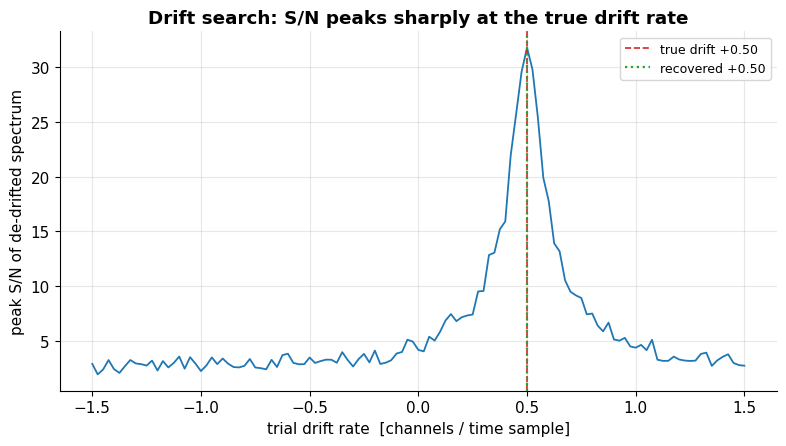

In [6]:
# S/N vs trial drift rate -- the matched-filter response, peaking at the truth.
fig, ax = plt.subplots(figsize=(8, 4.6))
ax.plot(result.drift_rates, result.snr, color="#1f77b4", lw=1.3)
ax.axvline(TRUE_DRIFT, color="#d62728", ls="--", lw=1.2,
           label=f"true drift {TRUE_DRIFT:+.2f}")
ax.axvline(result.best_drift, color="#2ca02c", ls=":", lw=1.6,
           label=f"recovered {result.best_drift:+.2f}")
ax.set_xlabel("trial drift rate  [channels / time sample]")
ax.set_ylabel("peak S/N of de-drifted spectrum")
ax.set_title("Drift search: S/N peaks sharply at the true drift rate")
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

The response peaks sharply at the injected drift and falls away on either side —
a clean **matched-filter** curve. Now let us look at the integrated spectra
themselves, to *see* the signal snap into focus at the right drift and smear away at
the wrong one.

peak of de-drifted spectrum at correct drift (+0.50): 250.5
peak at wrong drift (0.00, i.e. 'no drift')   : 44.0
-> the matched drift makes the tone ~5.7x taller.


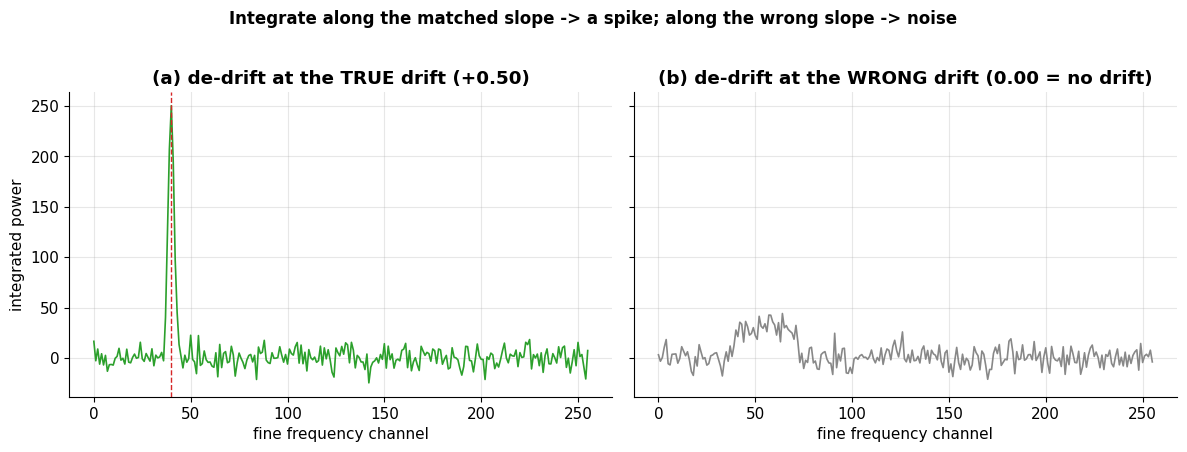

In [7]:
# De-drift at the RIGHT drift (the signal integrates into a spike)
# and at a WRONG drift (it washes out).
spectrum_right = seti.dedrift(waterfall, result.best_drift)
spectrum_wrong = seti.dedrift(waterfall, 0.0)   # assume no drift -> mismatched

peak_right = spectrum_right.max()
peak_wrong = spectrum_wrong.max()
print(f"peak of de-drifted spectrum at correct drift ({result.best_drift:+.2f}): "
      f"{peak_right:.1f}")
print(f"peak at wrong drift (0.00, i.e. 'no drift')   : {peak_wrong:.1f}")
print(f"-> the matched drift makes the tone ~{peak_right / peak_wrong:.1f}x taller.")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.4), sharey=True)

axes[0].plot(spectrum_right, color="#2ca02c", lw=1.2)
axes[0].axvline(np.argmax(spectrum_right), color="#d62728", ls="--", lw=1)
axes[0].set_title(f"(a) de-drift at the TRUE drift ({result.best_drift:+.2f})")
axes[0].set_xlabel("fine frequency channel")
axes[0].set_ylabel("integrated power")

axes[1].plot(spectrum_wrong, color="#888888", lw=1.2)
axes[1].set_title("(b) de-drift at the WRONG drift (0.00 = no drift)")
axes[1].set_xlabel("fine frequency channel")

fig.suptitle("Integrate along the matched slope -> a spike; along the wrong slope -> noise",
             y=1.02, fontsize=12, fontweight="bold")
fig.tight_layout()
plt.show()

Panel (a) is the payoff: at the matched drift the tone integrates into one clean
spike towering over the noise floor — that is a **detection**. Panel (b) shows what
happens if you guess the drift wrong (here, assume it does not drift at all): the
tone's power is spread across many channels and never rises above the noise. This is
why you *must* search drift rate, and why a real pipeline like `turboSETI` spends most
of its compute marching through $\dot\nu$.

## 4. Rejecting interference with an ON/OFF cadence

A drift search finds narrowband, drifting signals. Unfortunately, **so does human
technology** — and there is a *lot* of it. GPS, Starlink, aircraft transponders,
radar, cell towers, your microwave oven: the radio sky is drenched in artificial
narrowband signals, almost all of them ours. The field-notes lesson is blunt:

> *Your environment is full of fake signals. A genuine cosmic signal should behave
> like the sky, not like your kitchen.*
> — [`docs/field-notes.md`](https://github.com/joebarbere/jansky/blob/main/docs/field-notes.md),
> "RFI, and the discipline of not fooling yourself"

The same discipline that exposed the Parkes **perytons** (microwave ovens, not the
cosmos) governs SETI. The key tool is **geometry**: a real signal comes *from the
target star*; interference is local and arrives from everywhere. So you run an
**ON/OFF cadence** — a sequence like **ON–OFF–ON–OFF–ON–OFF**, nodding the telescope
between the target and nearby blank sky:

- A **true** technosignature appears in **every ON scan** (the beam is on the source)
  and in **no OFF scan** (the beam is off it). It blinks with the cadence.
- **Interference** does not care where the dish points; it appears in **all** scans,
  ON and OFF alike.

`seti.cadence_detection` encodes exactly this test: accept only if **all ON scans**
exceed a S/N threshold **and all OFF scans** fall below it. We simulate two cadences —
a genuine candidate (present only ON) and an interferer (present everywhere) — and
let the test sort them.

In [8]:
# A six-scan ON/OFF/ON/OFF/ON/OFF cadence. Each scan is its own waterfall, with
# its own noise (different seed), drift-searched independently.
PATTERN = ["ON", "OFF", "ON", "OFF", "ON", "OFF"]
CAND_DRIFT = 0.5     # the candidate's drift rate (channels per time sample)
CAND_SNR = 6.0       # bright enough to clear the cadence threshold when present
THRESHOLD = 8.0      # detection threshold on best-S/N (cadence_detection default)

def make_scan(present, *, drift, snr, seed):
    "One waterfall scan: a tone if present, else pure noise."
    return seti.drifting_tone(
        N_TIME, N_FREQ, drift_rate=drift, f0=F0, snr=snr, width=WIDTH,
        present=present, seed=seed,
    )

print(f"cadence pattern : {' -> '.join(PATTERN)}")
print(f"threshold       : best-S/N >= {THRESHOLD} counts as 'present'")
print("rule (cadence_detection): accept only if ALL ON >= threshold AND ALL OFF < threshold")

cadence pattern : ON -> OFF -> ON -> OFF -> ON -> OFF
threshold       : best-S/N >= 8.0 counts as 'present'
rule (cadence_detection): accept only if ALL ON >= threshold AND ALL OFF < threshold


In [9]:
# --- Scenario A: a genuine candidate -- tone present ONLY in the ON scans. ---
candidate_scans = []
for i, kind in enumerate(PATTERN):
    present = (kind == "ON")
    wf = make_scan(present, drift=CAND_DRIFT, snr=CAND_SNR, seed=100 + i)
    candidate_scans.append((kind, seti.drift_search(wf, trial_drifts)))

# --- Scenario B: interference -- a drifting tone present in EVERY scan. ---
rfi_scans = []
for i, kind in enumerate(PATTERN):
    wf = make_scan(True, drift=CAND_DRIFT, snr=CAND_SNR, seed=200 + i)
    rfi_scans.append((kind, seti.drift_search(wf, trial_drifts)))

print("best S/N per scan:")
print(f"  {'scan':>6} {'candidate':>12} {'interference':>14}")
for (k, rc), (_, ri) in zip(candidate_scans, rfi_scans):
    print(f"  {k:>6} {rc.best_snr:>12.1f} {ri.best_snr:>14.1f}")

best S/N per scan:
    scan    candidate   interference
      ON         53.2           46.4
     OFF          4.1           46.9
      ON         46.3           43.7
     OFF          4.5           55.6
      ON         48.2           44.9
     OFF          4.9           45.3


In [10]:
# Split each cadence into ON-results and OFF-results, then apply the test.
def split(scans):
    on = [r for (k, r) in scans if k == "ON"]
    off = [r for (k, r) in scans if k == "OFF"]
    return on, off

cand_on, cand_off = split(candidate_scans)
rfi_on, rfi_off = split(rfi_scans)

accept_candidate = seti.cadence_detection(cand_on, cand_off, threshold=THRESHOLD)
accept_rfi = seti.cadence_detection(rfi_on, rfi_off, threshold=THRESHOLD)

print(f"Scenario A (present only ON)  -> cadence_detection = {accept_candidate}  "
      f"{'ACCEPT (looks like a real signal)' if accept_candidate else 'reject'}")
print(f"Scenario B (present in ALL)   -> cadence_detection = {accept_rfi}  "
      f"{'accept' if accept_rfi else 'REJECT (interference: shows up off-target too)'}")

assert accept_candidate is True
assert accept_rfi is False
print("\n-> The cadence keeps the on-only candidate and throws out the everywhere interferer.")

Scenario A (present only ON)  -> cadence_detection = True  ACCEPT (looks like a real signal)
Scenario B (present in ALL)   -> cadence_detection = False  REJECT (interference: shows up off-target too)

-> The cadence keeps the on-only candidate and throws out the everywhere interferer.


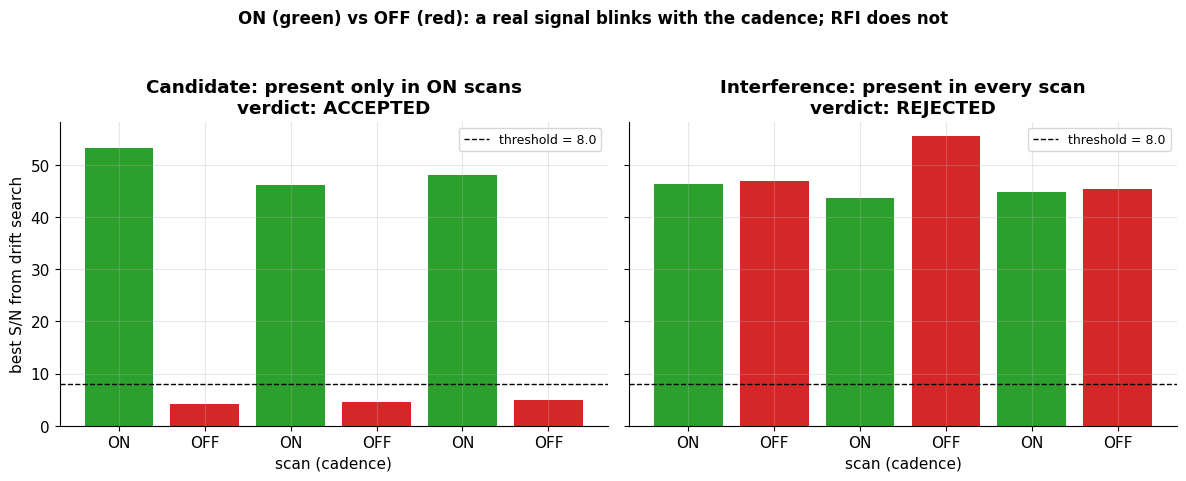

In [11]:
# Visualise the cadence: best-S/N per scan, ON vs OFF, for both scenarios.
scan_idx = np.arange(len(PATTERN))
cand_snrs = [r.best_snr for (_, r) in candidate_scans]
rfi_snrs = [r.best_snr for (_, r) in rfi_scans]
on_mask = np.array([k == "ON" for k in PATTERN])

fig, axes = plt.subplots(1, 2, figsize=(12, 4.6), sharey=True)
for ax, snrs, title, accepted in [
    (axes[0], cand_snrs, "Candidate: present only in ON scans", accept_candidate),
    (axes[1], rfi_snrs, "Interference: present in every scan", accept_rfi),
]:
    colors = ["#2ca02c" if m else "#d62728" for m in on_mask]
    ax.bar(scan_idx, snrs, color=colors)
    ax.axhline(THRESHOLD, color="k", ls="--", lw=1, label=f"threshold = {THRESHOLD}")
    ax.set_xticks(scan_idx)
    ax.set_xticklabels(PATTERN)
    ax.set_xlabel("scan (cadence)")
    verdict = "ACCEPTED" if accepted else "REJECTED"
    ax.set_title(f"{title}\nverdict: {verdict}")
    ax.legend(fontsize=9)
axes[0].set_ylabel("best S/N from drift search")
fig.suptitle("ON (green) vs OFF (red): a real signal blinks with the cadence; RFI does not",
             y=1.04, fontsize=12, fontweight="bold")
fig.tight_layout()
plt.show()

The left panel is what a real candidate looks like: tall green ON bars above the
threshold, short red OFF bars below it — the signal **blinks with the pointing**. The
right panel is interference: every bar is tall, ON and OFF alike, because the source
does not care where the telescope points. `cadence_detection` accepts the first and
rejects the second.

This is the single most powerful weapon in real SETI. Breakthrough Listen records
exactly this kind of ON/OFF/ON/OFF/ON/OFF cadence on every target, and the analysis
*requires* a hit to be present in the ONs and absent in the OFFs before it is even
worth a human's attention. It is the same "behave like the sky, not like my kitchen"
discipline from the FRB chapter, made into an observing strategy.

## 5. The Drake equation — a back-of-envelope for hope

How many civilisations might we actually be able to detect? In 1961, for the same
Green Bank meeting that launched modern SETI, **Frank Drake** wrote down a way to
*organise the ignorance* rather than resolve it. The **Drake equation** estimates
$N$, the number of communicating civilisations in our Galaxy right now, as a product
of factors:

$$
N \;=\; R_\star \cdot f_p \cdot n_e \cdot f_l \cdot f_i \cdot f_c \cdot L
$$

| Term | Meaning | Roughly known? |
|---|---|---|
| $R_\star$ | rate of star formation (stars / year) | **yes** — astrophysics |
| $f_p$ | fraction of stars with planets | **increasingly yes** — exoplanets |
| $n_e$ | habitable planets per such system | partly |
| $f_l$ | fraction where life arises | **no** |
| $f_i$ | fraction of those that develop intelligence | **no** |
| $f_c$ | fraction that broadcast detectably | **no** |
| $L$ | average lifetime of the communicative phase (years) | **no** — the killer |

The first two or three terms are real measurements. The last four are guesses
spanning *many orders of magnitude* — especially $L$, the longevity term, which alone
can swing the answer from "we are alone" to "the Galaxy is crowded." The equation's
value is not its output but its **structure**: it tells you exactly which unknowns
dominate, and it makes the smallness or vastness of the answer depend on assumptions
you can argue about explicitly.

In [12]:
def drake(R_star, f_p, n_e, f_l, f_i, f_c, L):
    # The Drake equation: expected number N of communicating civilisations.
    #   R_star : star-formation rate (stars per year)
    #   f_p    : fraction of stars with planets
    #   n_e    : habitable planets per planet-bearing system
    #   f_l    : fraction where life arises
    #   f_i    : fraction of those developing intelligence
    #   f_c    : fraction that broadcast detectably
    #   L      : mean lifetime of the communicative phase (years)
    return R_star * f_p * n_e * f_l * f_i * f_c * L


# A few plausible-but-arguable parameter sets. The terms on the right are guesses.
scenarios = {
    "Optimistic":  dict(R_star=3.0, f_p=1.0, n_e=0.5,  f_l=1.0,  f_i=1.0,  f_c=0.5,  L=1_000_000),
    "Drake's 1961": dict(R_star=1.0, f_p=0.5, n_e=2.0,  f_l=1.0,  f_i=0.01, f_c=0.01, L=10_000),
    "Moderate":    dict(R_star=1.5, f_p=1.0, n_e=0.2,  f_l=0.5,  f_i=0.1,  f_c=0.1,  L=10_000),
    "Pessimistic": dict(R_star=1.0, f_p=1.0, n_e=0.1,  f_l=0.1,  f_i=0.001, f_c=0.01, L=500),
}

print(f"{'scenario':<14}{'N (civilisations)':>20}")
print("-" * 34)
results = {}
for name, params in scenarios.items():
    N = drake(**params)
    results[name] = N
    print(f"{name:<14}{N:>20,.2f}")

span = max(results.values()) / min(v for v in results.values() if v > 0)
print(f"\nspread between optimistic and pessimistic: a factor of ~{span:,.0f}")
print("Same equation, defensible inputs -- the answer swings by orders of magnitude.")

scenario         N (civilisations)
----------------------------------
Optimistic              750,000.00
Drake's 1961                  1.00
Moderate                     15.00
Pessimistic                   0.00

spread between optimistic and pessimistic: a factor of ~15,000,000,000
Same equation, defensible inputs -- the answer swings by orders of magnitude.


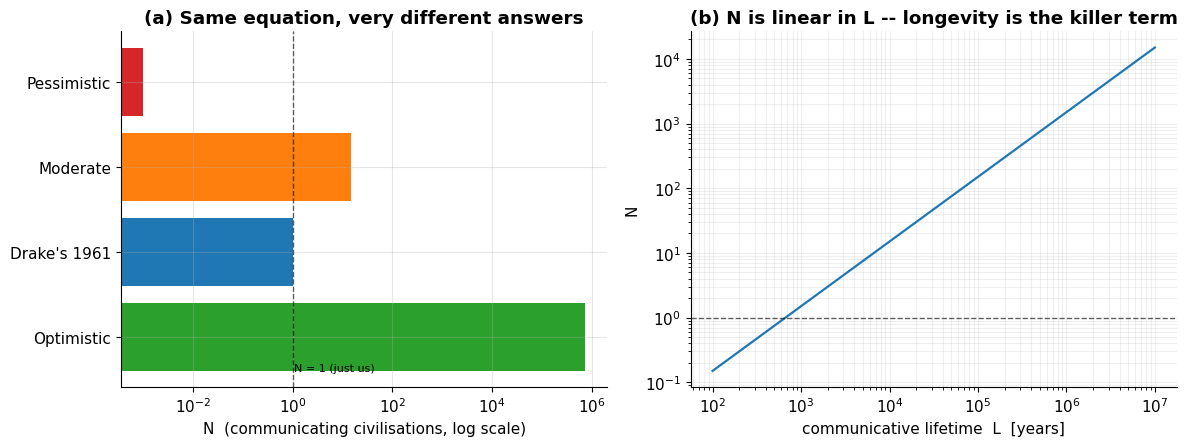

In [13]:
# Visualise how wildly N ranges -- and which term (L) drives it.
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))

# (a) N for each scenario, log scale -- the orders-of-magnitude spread.
names = list(results.keys())
vals = [max(results[n], 1e-3) for n in names]
axes[0].barh(names, vals, color=["#2ca02c", "#1f77b4", "#ff7f0e", "#d62728"])
axes[0].set_xscale("log")
axes[0].set_xlabel("N  (communicating civilisations, log scale)")
axes[0].set_title("(a) Same equation, very different answers")
axes[0].axvline(1.0, color="k", ls="--", lw=1, alpha=0.6)
axes[0].text(1.05, -0.4, "N = 1 (just us)", fontsize=8, color="k")

# (b) Sweep the longevity term L for the 'Moderate' scenario -- N is linear in L.
L_grid = np.logspace(2, 7, 100)          # 100 yr to 10 Myr
base = dict(scenarios["Moderate"])
del base["L"]
N_vs_L = [drake(L=L, **base) for L in L_grid]
axes[1].loglog(L_grid, N_vs_L, color="#1f77b4", lw=1.6)
axes[1].set_xlabel("communicative lifetime  L  [years]")
axes[1].set_ylabel("N")
axes[1].set_title("(b) N is linear in L -- longevity is the killer term")
axes[1].axhline(1.0, color="k", ls="--", lw=1, alpha=0.6)
axes[1].grid(True, which="both", alpha=0.2)

fig.tight_layout()
plt.show()

Panel (a): the *same* equation, fed defensible numbers, returns answers spanning
many orders of magnitude — from "we are effectively alone" to "the Galaxy hosts
millions." Panel (b): because $N \propto L$, the **longevity** of the communicative
phase alone moves the answer linearly across the whole range. A civilisation that
broadcasts for a century gives a very different sky than one that broadcasts for a
million years. The Drake equation does not tell us the answer — it tells us that the
answer depends, above all, on things we cannot yet measure. That uncertainty is the
*reason to keep searching*: the only way to pin down the right-hand terms is to look.

## Try it yourself

### Exercise 1 — How faint can you go? (vary drift / SNR)

In Section 2 the tone had peak `SNR = 4.0`. **Lower it** (try 3, 2, 1.5, 1, 0.7) and
rerun the drift search; watch `result.best_snr` slide toward the noise and, eventually,
`result.best_drift` stop matching `TRUE_DRIFT`. Then try a **steeper drift** (e.g.
`1.0`) or a **negative** one and confirm the search still finds it. This is the core
sensitivity-vs-search-size trade-off of every SETI pipeline.

In [14]:
# Exercise 1 starter -- sweep the injected SNR and check drift recovery.
print(f"{'SNR':>5}  {'recovered drift':>16}  {'best S/N':>9}  verdict")
for snr in (4.0, 3.0, 2.0, 1.5, 1.0, 0.7):
    wf = seti.drifting_tone(N_TIME, N_FREQ, drift_rate=TRUE_DRIFT, f0=F0,
                            snr=snr, width=WIDTH, present=True, seed=SEED)
    r = seti.drift_search(wf, trial_drifts)
    ok = "recovered" if abs(r.best_drift - TRUE_DRIFT) < 0.05 else "LOST"
    print(f"{snr:>5}  {r.best_drift:>16.3f}  {r.best_snr:>9.1f}  [{ok}]")
# Your turn: try drift_rate = 1.0 or -0.75, widen `trial_drifts`, change `width`.

  SNR   recovered drift   best S/N  verdict
  4.0             0.500       31.8  [recovered]
  3.0             0.500       23.9  [recovered]
  2.0             0.500       15.8  [recovered]


  1.5             0.500       11.9  [recovered]
  1.0             0.525        8.0  [recovered]
  0.7             0.475        5.9  [recovered]


<details>
<summary>Solution</summary>

**Faint end.** The starter table already shows the trend: as the injected `snr`
falls, `result.best_snr` slides toward the noise floor. The de-drift sums
$N_{\text{time}}=64$ rows, so the tone integrates coherently while the noise grows
like $\sqrt{N_{\text{time}}}$ — a matched-filter gain of $\sqrt{64}=8$. That is why a
per-row amplitude of just `snr` $\approx 1\sigma$ still yields an integrated
`best_snr` $\approx 8$. Push lower and the peak drops into the floor:

```python
# Average over many noise realisations to see where drift recovery actually breaks.
for snr in (0.7, 0.5, 0.3, 0.1):
    snrs, hits = [], 0
    for s in range(40):
        wf = seti.drifting_tone(N_TIME, N_FREQ, drift_rate=TRUE_DRIFT, f0=F0,
                                snr=snr, width=WIDTH, present=True, seed=1000 + s)
        r = seti.drift_search(wf, trial_drifts)
        snrs.append(r.best_snr)
        hits += abs(r.best_drift - TRUE_DRIFT) < 0.05
    print(f"snr={snr}: mean best_snr={np.mean(snrs):.1f}, recovered {hits/40:.0%} of the time")
```

This prints roughly

```
snr=0.7: mean best_snr=6.3, recovered 85% of the time
snr=0.5: mean best_snr=5.0, recovered 45% of the time
snr=0.3: mean best_snr=4.4, recovered 10% of the time
snr=0.1: mean best_snr=4.4, recovered  2% of the time
```

Around `snr` $\approx 0.5$ recovery becomes a coin flip, and below that `best_snr`
flattens at a **noise floor of $\sim 4.4$** — that is just the largest spurious peak
you expect when you take the max over $121$ trial drifts $\times$ a $256$-channel
spectrum of pure noise. At that point `best_drift` is set by *which noise bump won*,
not by the signal, so it stops tracking `TRUE_DRIFT`.

**Steeper / negative drift.** The search is symmetric in drift sign, so it finds these
just as well — provided the trial grid spans them and the tone stays on-band:

```python
for d in (1.0, -0.75, 1.3):
    wf = seti.drifting_tone(N_TIME, N_FREQ, drift_rate=d, f0=F0,
                            snr=4.0, width=WIDTH, present=True, seed=SEED)
    r = seti.drift_search(wf, trial_drifts)
    print(f"injected {d:+.2f} -> recovered {r.best_drift:+.3f}, best S/N {r.best_snr:.1f}")
```

gives

```
injected +1.00 -> recovered +1.000, best S/N 35.2
injected -0.75 -> recovered -0.750, best S/N 25.7
injected +1.30 -> recovered +1.325, best S/N 31.5
```

The recovered rate matches the truth to within the grid step $\Delta = 3/120 = 0.025$
channels/sample (note `+1.30` rounds to the nearest trial `+1.325`). A steeper drift
sweeps farther — `drift_rate=1.0` moves the tone $1.0\times 63 \approx 63$ channels,
from channel $40$ to $103$, still comfortably inside the $256$-channel band. If you
push the drift past the edge of `trial_drifts`, widen the grid
(`np.linspace(-4, 4, ...)`, mirroring Breakthrough Listen's $\pm 4$ Hz s$^{-1}$).

**The trade-off.** Lowering the detectable `snr` and widening the drift grid both buy
sensitivity, but every extra trial drift is more compute — exactly the
sensitivity-vs-search-size tension that `turboSETI` manages with its tree-search
de-drift instead of the brute-force loop used here.

</details>

### Exercise 2 — Design your own cadence

Section 4 used `ON OFF ON OFF ON OFF`. **Build a different cadence** — say
`ON OFF OFF ON OFF ON` — and a candidate that, through bad luck, is *missing from one
ON scan* (set `present=False` for one ON, mimicking a beacon that blinked off). Run
`cadence_detection` and confirm it is now **rejected**: a real technosignature must be
in **every** ON. Then make an interferer that happens to be **absent from the OFFs by
chance** and see whether it sneaks through — this is why real surveys demand many
scans.

In [15]:
# Exercise 2 starter -- a candidate that drops out of one ON scan is rejected.
my_pattern = ["ON", "OFF", "OFF", "ON", "OFF", "ON"]
# Force the candidate to be absent from the 2nd ON scan (index 3): it 'blinked off'.
present_flags = [True, False, False, False, False, True]   # ON at idx 3 -> False!

scans = []
for i, (kind, present) in enumerate(zip(my_pattern, present_flags)):
    wf = make_scan(present and kind == "ON", drift=CAND_DRIFT, snr=CAND_SNR, seed=300 + i)
    scans.append((kind, seti.drift_search(wf, trial_drifts)))

on = [r for (k, r) in scans if k == "ON"]
off = [r for (k, r) in scans if k == "OFF"]
verdict = seti.cadence_detection(on, off, threshold=THRESHOLD)
print("ON-scan best S/N :", [f"{r.best_snr:.1f}" for r in on])
print("OFF-scan best S/N:", [f"{r.best_snr:.1f}" for r in off])
print(f"cadence_detection -> {verdict}  "
      f"({'ACCEPT' if verdict else 'REJECT -- missing from one ON scan'})")
# Your turn: design a pattern; make an interferer that's accidentally weak in the OFFs.

ON-scan best S/N : ['40.5', '4.3', '48.1']
OFF-scan best S/N: ['4.5', '5.2', '4.2']
cadence_detection -> False  (REJECT -- missing from one ON scan)


<details>
<summary>Solution</summary>

**A candidate that blinked off is rejected.** The starter sets `present=False` for the
second ON scan (index 3 of `["ON","OFF","OFF","ON","OFF","ON"]`), so that ON scan is
pure noise:

```
ON-scan best S/N : ['40.5', '4.3', '48.1']
OFF-scan best S/N: ['4.5', '5.2', '4.2']
cadence_detection -> False  (REJECT -- missing from one ON scan)
```

`cadence_detection` requires **all** ON scans to clear the threshold
(`all(r.best_snr >= threshold ...)`), so a single missing ON ($4.3 < 8.0$) is enough to
veto the whole cadence. That is the intended discipline: a genuine technosignature from
the target must be in **every** ON pointing, so a beacon that happens to be off during
one scan is conservatively thrown away rather than half-believed.

**An interferer that is absent from the OFFs by chance can sneak through.** This is the
flip side, and the real reason surveys demand many scans. Build an interferer that is
present in all three ON scans but — through bad luck of the noise/timing — happens to
register below threshold in all three OFFs:

```python
pattern = ["ON", "OFF", "ON", "OFF", "ON", "OFF"]
flags   = [True, False, True, False, True, False]   # "present" only where we sampled it ON
scans = []
for i, (k, p) in enumerate(zip(pattern, flags)):
    wf = make_scan(p, drift=CAND_DRIFT, snr=CAND_SNR, seed=500 + i)
    scans.append((k, seti.drift_search(wf, trial_drifts)))
on  = [r for (k, r) in scans if k == "ON"]
off = [r for (k, r) in scans if k == "OFF"]
print("ON :", [f"{r.best_snr:.1f}" for r in on])
print("OFF:", [f"{r.best_snr:.1f}" for r in off])
print("cadence_detection ->", seti.cadence_detection(on, off, threshold=THRESHOLD))
```

prints

```
ON : ['44.1', '48.1', '44.5']
OFF: ['4.0', '4.7', '3.9']
cadence_detection -> True
```

Here the test returns `True` even though, by construction, this is interference that
simply was not sampled during the OFFs. With only three OFF scans, the chance of an
intermittent or directional interferer dodging all of them is not negligible — so the
ON/OFF test is necessary but not sufficient on its own. Real surveys (Breakthrough
Listen) stack the odds against false positives by using longer cadences, many targets,
re-observation of any hit, and human vetting. One clean cadence is a *candidate*, never
yet a *discovery* — exactly the lesson of the unrepeatable "Wow!" signal.

</details>

### Exercise 3 — Tweak the Drake terms

Pick the term you think is *least* known (many argue it is $f_l$, $f_i$, or $L$) and
sweep it across a few orders of magnitude while holding the others at the "Moderate"
values. Plot $N$ against your chosen term on a log–log axis. How many orders of
magnitude does $N$ move? Then set $f_i = f_c = 1$ (suppose intelligence and
broadcasting are *inevitable* once life exists) — does the search look hopeful?

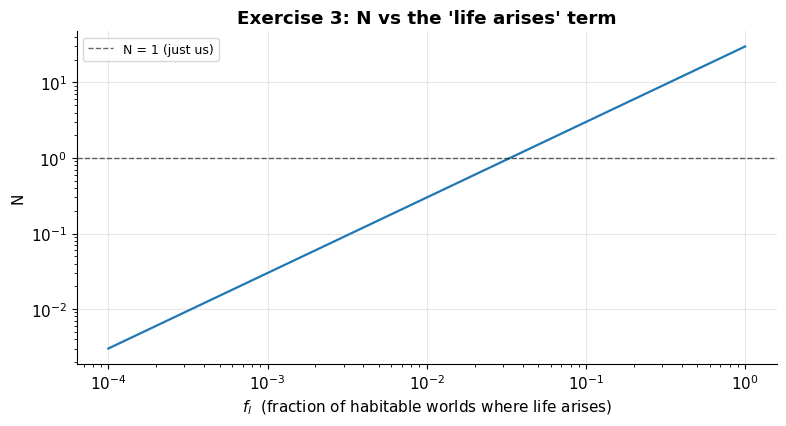

In [16]:
# Exercise 3 starter -- sweep f_l (fraction of habitable worlds where life arises).
base = dict(scenarios["Moderate"])
del base["f_l"]
f_l_grid = np.logspace(-4, 0, 100)        # 1-in-10,000 up to certain
N_vs_fl = [drake(f_l=f, **base) for f in f_l_grid]

fig, ax = plt.subplots(figsize=(8, 4.4))
ax.loglog(f_l_grid, N_vs_fl, color="#1f77b4", lw=1.6)
ax.axhline(1.0, color="k", ls="--", lw=1, alpha=0.6, label="N = 1 (just us)")
ax.set_xlabel(r"$f_l$  (fraction of habitable worlds where life arises)")
ax.set_ylabel("N")
ax.set_title("Exercise 3: N vs the 'life arises' term")
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()
# Your turn: sweep f_i or L instead; set f_i = f_c = 1 and recompute every scenario.

<details>
<summary>Solution</summary>

**Sweeping the least-known term.** Because the Drake equation is a plain **product**,
$N$ is *linear* in every factor: scale any one term by $10^k$ and $N$ scales by the
same $10^k$. On a log–log plot of $N$ vs that term you get a **straight line of slope
1**. Sweeping $f_l$ across the four orders of magnitude in the starter
(`np.logspace(-4, 0, 100)`), with the other terms held at the "Moderate" values, $N$
moves over exactly those four orders:

```python
base = dict(scenarios["Moderate"]); del base["f_l"]
for f in (1e-4, 1e-2, 1.0):
    print(f"f_l={f:.0e} -> N={drake(f_l=f, **base):.4g}")
```

```
f_l=1e-04 -> N=0.003
f_l=1e-02 -> N=0.3
f_l=1e+00 -> N=30
```

So the answer swings from "we are alone in the Galaxy" ($N \ll 1$) to "dozens of
neighbours" ($N=30$) purely on a term nobody can yet measure. You would see the same
slope-1 line sweeping $f_i$, $f_c$, or $L$ instead — these poorly-known terms are
*degenerate*, which is why the equation's honest output is a range, not a number.

**Suppose intelligence and broadcasting are inevitable** ($f_i = f_c = 1$). This is the
most optimistic move available for those two terms. Recompute every scenario:

```python
for name, p in scenarios.items():
    q = dict(p, f_i=1.0, f_c=1.0)
    print(f"{name:<12} N = {drake(**q):,.1f}  (was {drake(**p):,.2f})")
```

```
Optimistic   N = 1,500,000.0  (was 750,000.00)
Drake's 1961 N = 10,000.0     (was 1.00)
Moderate     N = 1,500.0      (was 15.00)
Pessimistic  N = 5.0          (was 0.00)
```

The verdict is genuinely encouraging — but conditionally. Forcing $f_i = f_c = 1$ lifts
the **Moderate** case from $15$ to $\sim 1500$ and rescues the **Pessimistic** case from
"effectively zero" up to $\sim 5$. Yet even then the Pessimistic answer stays small,
because its tiny $n_e$, $f_l$, and especially its short $L=500$ yr still throttle it.
The takeaway matches the chapter's theme: optimism about the *biological* terms makes
the sky look populated, but **longevity** ($L$) — how long a civilisation keeps
broadcasting — remains the term that decides whether anyone is transmitting *right now*,
in the same epoch we happen to be listening.

</details>

## Recap

- A radio **technosignature** is a **narrowband** signal — nature makes broadband
  emission, so a coherent tone a few hertz wide in a billion is the mark of a
  transmitter. The search axes are frequency $\times$ time $\times$ **Doppler drift**
  $\times$ sky, a vast haystack.
- Relative **acceleration** (planetary rotation and orbit) Doppler-shifts a fixed
  rest frequency into a linear **frequency drift** $\dot f = f_0 a_\parallel / c$, a
  fraction of a Hz s$^{-1}$ to a few Hz s$^{-1}$. On a fine **waterfall** the signal
  traces a sloped diagonal; `seti.drifting_tone` simulates one.
- The **drift-rate matched filter** — `seti.dedrift` / `seti.drift_search` — shifts
  each time row by the trial drift and sums: at the true rate the tone integrates
  into a clean spike, at the wrong rate it washes out. The S/N-vs-drift curve peaks at
  the truth. **`turboSETI` ([Chapter 16](16_data_formats_and_ecosystem.ipynb)) runs
  exactly this at scale** over Breakthrough Listen filterbank data.
- The **ON/OFF cadence** rejects interference: a true signal appears in **every ON**
  scan and **no OFF** scan, while RFI floods all scans. `seti.cadence_detection`
  encodes the test — the observing-strategy form of the "behave like the sky, not like
  my kitchen" RFI discipline ([`docs/field-notes.md`](https://github.com/joebarbere/jansky/blob/main/docs/field-notes.md)).
- The **Drake equation** organises our ignorance into seven factors; with defensible
  inputs $N$ swings by many orders of magnitude, driven above all by the longevity
  term $L$. Its value is structural, not numerical.

## What's next

You now have the whole conceptual SETI pipeline — narrowband channelisation, the
Doppler-drift matched filter, and cadence-based RFI rejection — in runnable form. The
real thing is the **same idea at scale**:

- [**Chapter 16**](16_data_formats_and_ecosystem.ipynb) shows the data plumbing:
  **GUPPI raw** voltages from the **GBT** / Breakthrough Listen, reduced by `rawspec`
  to filterbank, then searched by `turboSETI` (the `seti` extra). Pull a real
  Breakthrough Listen `.h5` waterfall and run it for yourself.
- The facilities are real and bookable on paper: the **Allen Telescope Array** (the
  first array built for SETI), **FAST**, **MeerKAT**, and the GBT/Parkes — all in
  [`docs/telescopes.md`](https://github.com/joebarbere/jansky/blob/main/docs/telescopes.md)
  — and the projects in [`docs/projects.md`](https://github.com/joebarbere/jansky/blob/main/docs/projects.md).
- And the open question remains exactly where Drake left it in 1961: the only way to
  measure the right-hand terms of his equation is to keep looking.